In [1]:
import sys
import os
import pandas as pd
import numpy as np
import pickle
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy.stats import norm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from MODELS.xgboostModel import *
from MODELS.ngboostModel import fit_ngboost_split, predict_mean_variance_split, validate_production_model
from ngboost.distns import Normal

# Try to import NegativeBinomial, fall back to Normal if not available
try:
    from ngboost.distns import NegativeBinomial
except ImportError:
    print("Warning: NegativeBinomial not available in this NGBOOST version. Using Normal distribution.")
    print("Note: You can still use Negative Binomial for probability calculations.")
    NegativeBinomial = Normal  # Use Normal as fallback

Note: You can still use Negative Binomial for probability calculations.


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/nba_model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df in [s20, s21, s22, s23, s24, s25, s26]:
    df.sort_values(['PLAYER_ID', 'GAME_DATE'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['GUARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['GUARD'] * round(df['OPP_GUARD_DEF_RATING'] / df['LEAGUE_AVG_GUARD_DEF_RATING'], 2)
    df['FORWARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['FORWARD'] * round(df['OPP_FORWARD_DEF_RATING'] / df['LEAGUE_AVG_FORWARD_DEF_RATING'], 2)
    df['CENTER_DEF_RATING_OVER_LEAGUE_AVG'] = df['CENTER'] * round(df['OPP_CENTER_DEF_RATING'] / df['LEAGUE_AVG_CENTER_DEF_RATING'], 2)
    df['POSS_VARIANCE_STABILITY'] = round(df['POSS_VOLATILITY_10_TO_DATE'] / (df['POSS_VOLATILITY_40_TO_DATE'] + 0.001), 2)
    df['MIN_CEILING_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['MIN_FLOOR_L5'] = df.groupby('PLAYER_ID')['MIN'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['MIN_CEILING_L5_DELTA'] = (df['MIN_CEILING_L5'] - df['MIN_AVG_TO_DATE']).round(2)
    df['MIN_FLOOR_L5_DELTA'] = (df['MIN_FLOOR_L5'] - df['MIN_AVG_TO_DATE']).round(2)
    df['PTS_CEILING_L5'] = df.groupby('PLAYER_ID')['PTS'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['PTS_FLOOR_L5'] = df.groupby('PLAYER_ID')['PTS'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['PTS_CEILING_L5_DELTA'] = (df['PTS_CEILING_L5'] - df['PTS_AVG_TO_DATE']).round(2)
    df['PTS_FLOOR_L5_DELTA'] = (df['PTS_FLOOR_L5'] - df['PTS_AVG_TO_DATE']).round(2)
    df['USG_CEILING_L5'] = df.groupby('PLAYER_ID')['USG_PCT'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).max().round(2))
    df['USG_FLOOR_L5'] = df.groupby('PLAYER_ID')['USG_PCT'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).min().round(2))
    df['USG_CEILING_L5_DELTA'] = (df['USG_CEILING_L5'] - df['USG_PCT_AVG_TO_DATE']).round(2)
    df['USG_FLOOR_L5_DELTA'] = (df['USG_FLOOR_L5'] - df['USG_PCT_AVG_TO_DATE']).round(2)
    df['STARTING_x_MIN_AVG'] = df['STARTING'] * df['MIN_AVG_TO_DATE']
    df['STARTING_x_MIN_CEILING'] = df['STARTING'] * df['MIN_CEILING_L5']
    df['USG_PER_MIN'] = df['USG_PCT_AVG_TO_DATE'] / df['MIN_AVG_TO_DATE'] + 0.001
    df['SPD_L5_OVER_BASELINE'] = df['SPD_ROLLING_AVG_5'] / df['SPD_AVG_TO_DATE']
    df['SPD_L10_OVER_BASELINE'] = df['SPD_ROLLING_AVG_10'] / df['SPD_AVG_TO_DATE']

train_df = pd.concat([s22,s23,s24,s25])
val_df = s26
# test_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")
# test_df.sample()

BEFORE FILTERING:
Train set: 104668 samples
Val set: 6575 samples


In [3]:
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'GAMES_PLAYED']

# Define criteria for "relevant players"
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 12) &      
    (player_season_avg['GAMES_PLAYED'] >= 8)
]['PLAYER_ID']

# Filter training data to only relevant players
train_df = train_df[train_df['PLAYER_ID'].isin(relevant_players)]
train_df = train_df[
    (train_df['PTS'] <= 50) &  
    (train_df['MIN'] >= 8) &
    (train_df['MIN'] <= 48) &
    (train_df['USG_PCT'] <= 0.4)    
]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = val_df[val_df['PLAYER_ID'].isin(relevant_players)]
val_df = val_df[
    (val_df['PTS'] <= 50) &  
    (val_df['MIN'] >= 8) &
    (val_df['MIN'] <= 48) &
    (val_df['USG_PCT'] <= 0.4)    
]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

# test_df = test_df[test_df['PLAYER_ID'].isin(relevant_players)]
# test_df = test_df[
#     (test_df['PTS'] <= 45) &  
#     (test_df['MIN'] >= 8) &
#     (test_df['MIN'] <= 40) &
#     (test_df['USG_PCT'] <= 0.4)    
# ]
# test_df = test_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print("AFTER FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")

AFTER FILTERING:
Train set: 85061 samples
Val set: 4508 samples


In [4]:
USG_features = [
    # Player context
    'STARTING', 
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'LINEUP_FGA_SHARE_AVG', 
    'USG_PCT_AVG_TO_DATE', 
    'USG_PCT_L5_OVER_BASELINE',
    'USG_PER_MIN',
]
USG_target = 'USG_PCT'
print(f"len(USG_features): {len(USG_features)}")
"""
# ADD THESE:
ON_OFF_STAR_PG
ON_OFF_PRIMARY_SCORER
ON_OFF_SECOND_CREATOR
LINEUP_USG_SHARE_AVG
LINEUP_FGA_SHARE_AVG
EXPECTED_TOUCHES
PRIMARY_HANDLER_RATE
MATCHUP_DOUBLE_TEAM_RATE
MATCHUP_PNR_COVERAGE
"""

len(USG_features): 7


'\n# ADD THESE:\nON_OFF_STAR_PG\nON_OFF_PRIMARY_SCORER\nON_OFF_SECOND_CREATOR\nLINEUP_USG_SHARE_AVG\nLINEUP_FGA_SHARE_AVG\nEXPECTED_TOUCHES\nPRIMARY_HANDLER_RATE\nMATCHUP_DOUBLE_TEAM_RATE\nMATCHUP_PNR_COVERAGE\n'

In [5]:
MIN_features = [
    # Player info
    'STARTING',
    'STAR_SAT_OUT', #new
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'MIN_CEILING_L5_DELTA',
    'MIN_FLOOR_L5_DELTA',
    'STARTING_x_MIN_AVG',
    'STARTING_x_MIN_CEILING',

    # Baseline minute distribution
    'MIN_AVG_TO_DATE',
    'MIN_L5_OVER_BASELINE',
    'MIN_L7_OVER_BASELINE',
    'MIN_L10_OVER_BASELINE',
    'MIN_STD_5_TO_DATE',
    'MIN_STD_10_TO_DATE',
    'MIN_BOOST_STAR_OUT',


    'SPD_L5_OVER_BASELINE', #new
    'SPD_L10_OVER_BASELINE', #new

    # Matchup & location expectational
    'MIN_EXPECTATION_LOCATION',
    'MATCHUP_MIN_DELTA',

    # Team context – keep only strongest predictors
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',

    # Opponent effects
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',
]
MIN_target = 'MIN'
print(f"len(MIN_features): {len(MIN_features)}")
"""
# ADD:
AVAILABLE_GUARDS
AVAILABLE_WINGS
AVAILABLE_BIGS
OUT_SAME_POSITION_COUNT     # massive improvement

TEAM_ROTATION_STD
COACH_ROTATION_TIGHTNESS

SPREAD                      # blowout indicator
BLOWOUT_RISK
TRAVEL_DISTANCE_LAST_3_DAYS
REST_DAYS_TEAM_AVG
"""

len(MIN_features): 23


'\n# ADD:\nAVAILABLE_GUARDS\nAVAILABLE_WINGS\nAVAILABLE_BIGS\nOUT_SAME_POSITION_COUNT     # massive improvement\n\nTEAM_ROTATION_STD\nCOACH_ROTATION_TIGHTNESS\n\nSPREAD                      # blowout indicator\nBLOWOUT_RISK\nTRAVEL_DISTANCE_LAST_3_DAYS\nREST_DAYS_TEAM_AVG\n'

In [6]:
# Train cascading model: MIN -> USG_PCT -> PTS
cascading_models = train_cascading_model(
    train_data=train_df,
    val_data=val_df,
    min_features=MIN_features,
    usg_features=USG_features,
    date_column='GAME_DATE',
    player_column='PLAYER_ID'
)

# Extract models and metrics
min_model = cascading_models['min_model']
usg_model = cascading_models['usg_model']
# pts_model = cascading_models['pts_model']
metrics = cascading_models['metrics']

print("\n" + "="*70)
print("CASCADING MODEL SUMMARY")
print("="*70)
print(f"\nMIN Model - R²: {metrics['MIN']['R2']:.3f}, RMSE: {metrics['MIN']['RMSE']:.3f}")
print(f"USG_PCT Model - R²: {metrics['USG_PCT']['R2']:.3f}, RMSE: {metrics['USG_PCT']['RMSE']:.3f}")



TRAINING CASCADING MODEL: MIN -> USG_PCT
(PTS will use Negative Binomial model separately)

STEP 1: Training MIN Model

TRAINING XGBOOST MODEL

📅 Step 1: Sorting by date...
   Training: 2021-10-21 to 2025-04-13
   Validation: 2025-10-23 to 2025-11-30

🧹 Step 2: Removing rows with missing target...
   Training samples: 85061
   Validation samples: 4508

📊 Step 3: Preparing features...

🔧 Step 4: Handling NaN values in features...
   • Filled 11322 NaN in training features
   • Filled 2231 NaN in validation features
   • Remaining NaN: 0

⚖️  Step 5: Creating sample weights...
   ✓ Applied 3x weight to last 15 games per player

🤖 Step 6: Training XGBoost...
   ✓ Training stopped at iteration 889

📈 Step 7: Evaluating on validation...

   VALIDATION METRICS:
   • RMSE: 5.231
   • MAE:  4.062
   • R²:   0.594

   Predictions: min=13.65, max=36.85, mean=25.66
   Actual:      min=8.05, max=47.43, mean=25.65

🔄 Step 8: Retraining on combined data...
   ✓ Final model trained on 89569 games

✅

In [7]:
# Prepare training data with predicted MIN and USG
# We need to add predicted MIN and USG to our datasets

def add_predicted_min_usg(df, min_model, usg_model, min_features, usg_features):
    """Add predicted MIN and USG_PCT to dataframe using trained models"""
    df = df.copy()
    
    # Predict MIN first
    X_min = df[min_features].fillna(0)
    df['PREDICTED_MIN'] = min_model.predict(X_min)
    
    # Predict USG using predicted MIN
    X_usg = df[usg_features].copy()
    X_usg['PREDICTED_MIN'] = df['PREDICTED_MIN']
    X_usg = X_usg.fillna(0)
    df['PREDICTED_USG_PCT'] = usg_model.predict(X_usg)
    
    return df

# Add predictions to train and val sets
print("\n📊 Step 1: Adding predicted MIN and USG to datasets...")
train_df_with_preds = add_predicted_min_usg(train_df, min_model, usg_model, MIN_features, USG_features)
val_df_with_preds = add_predicted_min_usg(val_df, min_model, usg_model, MIN_features, USG_features)

print(f"   Training samples: {len(train_df_with_preds)}")
print(f"   Validation samples: {len(val_df_with_preds)}")
print(f"   PREDICTED_MIN range: {train_df_with_preds['PREDICTED_MIN'].min():.1f} - {train_df_with_preds['PREDICTED_MIN'].max():.1f}")
print(f"   PREDICTED_USG_PCT range: {train_df_with_preds['PREDICTED_USG_PCT'].min():.3f} - {train_df_with_preds['PREDICTED_USG_PCT'].max():.3f}")



📊 Step 1: Adding predicted MIN and USG to datasets...
   Training samples: 85061
   Validation samples: 4508
   PREDICTED_MIN range: 9.3 - 45.9
   PREDICTED_USG_PCT range: 0.110 - 0.299



SHAP ANALYSIS:
   Model expects: 23 features
   Test data has: 23 features
------------------------------
Top 15 Features by SHAP importance:
  STARTING_x_MIN_CEILING         2.9451
  MIN_AVG_TO_DATE                1.8113
  STARTING                       1.0680
  STARTING_x_MIN_AVG             0.8313
  MIN_L5_OVER_BASELINE           0.4232
  MIN_BOOST_STAR_OUT             0.3706
  USUAL_STARTERS_AVAILABLE       0.2829
  MIN_EXPECTATION_LOCATION       0.2487
  MIN_L10_OVER_BASELINE          0.1876
  PLAYER_DAYS_REST               0.1875
  MIN_CEILING_L5_DELTA           0.1594
  MIN_L7_OVER_BASELINE           0.1569
  STAR_SAT_OUT                   0.1550
  MIN_FLOOR_L5_DELTA             0.1548
  MIN_STD_5_TO_DATE              0.1431


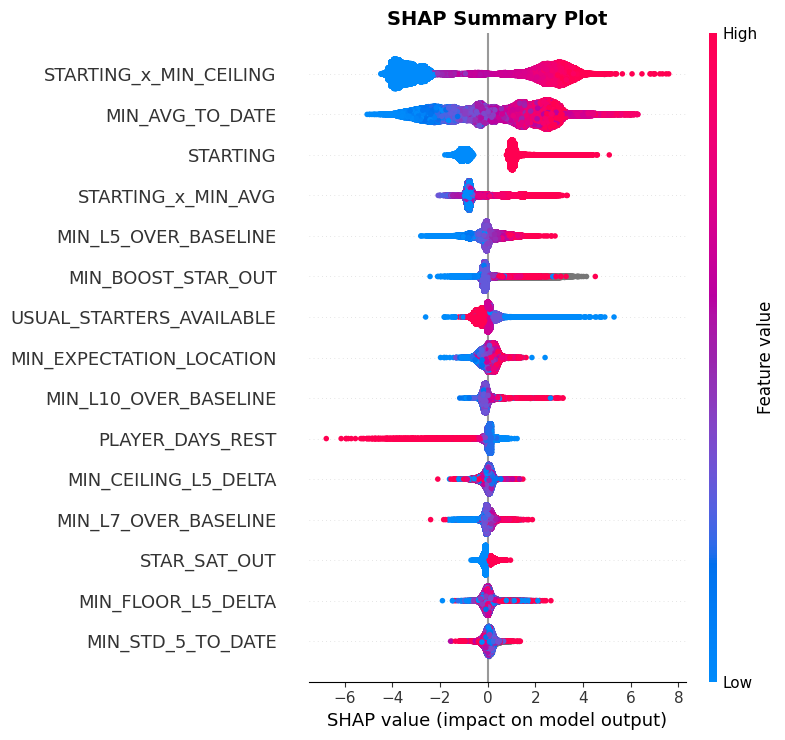

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.75
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
analyze_shap(min_model, train_df_with_preds, MIN_features, 'MIN')

In [9]:
# PTS Features for NGBOOST
PTS_features = [
    'STARTING',
    'GAMES_PLAYED_TO_DATE',
    'PTS_CEILING_L5_DELTA', #new
    'PTS_FLOOR_L5_DELTA', #new

    # Predicted upstream values (most important)
    'PREDICTED_MIN',
    'PREDICTED_USG_PCT',
    'PREDICTED_MIN_x_PREDICTED_USG_PCT',  # Interaction term
    
    # Baseline stats
    'PTS_AVG_TO_DATE',
    'PTS_L5_OVER_BASELINE',
    'PTS_L10_OVER_BASELINE', #new
    'PTS_STD_5_TO_DATE',
    'PTS_BOOST_STAR_OUT', #new
    'PTS_EXPECTATION_LOCATION', #new
    
    'FGA_AVG_TO_DATE',
    'FGA_L5_OVER_BASELINE',
    'FGA_L10_OVER_BASELINE',
    'FGA_BOOST_STAR_OUT', #new
    'FGA_EXPECTATION_LOCATION', #new

    'FTA_AVG_TO_DATE',
    'FTA_L5_OVER_BASELINE',
    'FTA_L10_OVER_BASELINE',
    'FTA_BOOST_STAR_OUT', #new
    'FTA_EXPECTATION_LOCATION', #new

    'FG3A_AVG_TO_DATE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_L10_OVER_BASELINE',
    'FG3A_BOOST_STAR_OUT', #new
    'FG3A_EXPECTATION_LOCATION', #new
    
    'PLUS_MINUS_AVG_TO_DATE',
    'PLUS_MINUS_L5_OVER_BASELINE',
    'PLUS_MINUS_L10_OVER_BASELINE',
    'PLUS_MINUS_BOOST_STAR_OUT', #new
    'PLUS_MINUS_EXPECTATION_LOCATION', #new
    
    'FG_PCT_AVG_TO_DATE',
    'FG_PCT_L5_OVER_BASELINE',
    'FG_PCT_L10_OVER_BASELINE',
    'FG_PCT_BOOST_STAR_OUT', #new
    'FG_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FG_PCT_DELTA', #new

    'FG3_PCT_AVG_TO_DATE',
    'FG3_PCT_L5_OVER_BASELINE',
    'FG3_PCT_L10_OVER_BASELINE',
    'FG3_PCT_BOOST_STAR_OUT',
    'FG3_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FG3_PCT_DELTA', #new

    'FT_PCT_AVG_TO_DATE',
    'FT_PCT_L5_OVER_BASELINE',
    'FT_PCT_L10_OVER_BASELINE',
    'FT_PCT_BOOST_STAR_OUT',
    'FT_PCT_EXPECTATION_LOCATION',
    'MATCHUP_FT_PCT_DELTA', #new

    'TS_PCT_AVG_TO_DATE',
    'TS_PCT_L5_OVER_BASELINE',
    'TS_PCT_L10_OVER_BASELINE',
    'TS_PCT_BOOST_STAR_OUT', #new
    'TS_PCT_EXPECTATION_LOCATION', #new
    'MATCHUP_TS_PCT_DELTA', #new
    
    # VARIANCE STABILITY
    'PTS_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FTA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'POSS_VARIANCE_STABILITY',
    'USG_PCT_VARIANCE_STABILITY',
    'TS_PCT_VARIANCE_STABILITY',

    # Team/Opponent context
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'EXPECTED_PACE',
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',
    
    # Positional defense
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
]

# Create interaction term
train_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    train_df_with_preds['PREDICTED_MIN'] * train_df_with_preds['PREDICTED_USG_PCT']
)
val_df_with_preds['PREDICTED_MIN_x_PREDICTED_USG_PCT'] = (
    val_df_with_preds['PREDICTED_MIN'] * val_df_with_preds['PREDICTED_USG_PCT']
)

# Filter to only rows where we have all features
# Include PLAYER_ID for sample weights (not in features list)
train_df_pts = train_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()
val_df_pts = val_df_with_preds[['PTS', 'PLAYER_ID'] + PTS_features].copy()

# Note: NGBOOST handles NaN values internally, no need to fill here
print(f"\n📊 Step 2: Preparing feature matrices...")
print(f"   Training samples: {len(train_df_pts)}")
print(f"   Validation samples: {len(val_df_pts)}")
print(f"   Features: {len(PTS_features)}")
print(f"   Points range: {train_df_pts['PTS'].min()} - {train_df_pts['PTS'].max()}")
print(f"   Mean points: {train_df_pts['PTS'].mean():.2f}")



📊 Step 2: Preparing feature matrices...
   Training samples: 85061
   Validation samples: 4508
   Features: 72
   Points range: 0 - 50
   Mean points: 12.19


In [10]:
# Train NGBOOST model for points
print(f"\n🤖 Step 3: Training NGBOOST model for points...")
print(f"   Training on {len(train_df_pts)} samples")

pts_mean_model, pts_var_model, calibration_factor = fit_ngboost_split(
    train_df=train_df_pts,
    val_df=val_df_pts,
    features=PTS_features,
    target_col='PTS',
    distribution=NegativeBinomial,
    player_col='PLAYER_ID',
    recent_n=30,
    recent_weight=2.0,
    variance_recent_weight=1.0,
    variance_lr=0.05,
    variance_max_depth=6,
    variance_n_estimators=600,
    variance_calibration_factor=3.5,
    target_transform=None,
    boost_high_scorers=True,
    high_scorer_percentile=75,
    high_scorer_boost=2.0
)

print(f"\n✅ NGBOOST training complete!")
print(f"   Calibration factor: {calibration_factor}")



🤖 Step 3: Training NGBOOST model for points...
   Training on 85061 samples
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.

✅ NGBOOST training complete!
   Calibration factor: 3.5


In [11]:
# Evaluate NGBOOST model on validation set
print(f"\n📈 Step 4: Evaluating NGBOOST model on validation set...")

# Get predictions
mu_val, variance_val = predict_mean_variance_split(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, calibration_factor, prediction_type='mean'
)

# Convert to arrays
mu_val = np.array(mu_val).flatten()
sigma_val = np.sqrt(np.array(variance_val).flatten())
y_val_actual = val_df_pts['PTS'].values

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val_actual, mu_val))
mae = mean_absolute_error(y_val_actual, mu_val)
r2 = r2_score(y_val_actual, mu_val)

print(f"\n   VALIDATION METRICS:")
print(f"   • RMSE: {rmse:.3f}")
print(f"   • MAE:  {mae:.3f}")
print(f"   • R²:   {r2:.3f}")
print(f"\n   Predictions: min={mu_val.min():.2f}, max={mu_val.max():.2f}, mean={mu_val.mean():.2f}")
print(f"   Actual:      min={y_val_actual.min():.2f}, max={y_val_actual.max():.2f}, mean={y_val_actual.mean():.2f}")
print(f"   Sigma:       min={sigma_val.min():.2f}, max={sigma_val.max():.2f}, mean={sigma_val.mean():.2f}")

# Store metrics
pts_metrics = {
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

# Calibration Check
print(f"\n🔍 Step 5: Calibration Check...")
standardized = validate_production_model(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 'PTS',
    calibration_factor=calibration_factor,
    prediction_type='median',
    show_by_score_range=True
)


📈 Step 4: Evaluating NGBOOST model on validation set...

   VALIDATION METRICS:
   • RMSE: 5.992
   • MAE:  4.636
   • R²:   0.519

   Predictions: min=2.24, max=31.86, mean=12.63
   Actual:      min=0.00, max=49.00, mean=12.63
   Sigma:       min=2.42, max=7.36, mean=5.47

🔍 Step 5: Calibration Check...
=== CALIBRATION CHECK (median) ===
Standardized residuals mean: 0.008 (should be ~0)
Standardized residuals std: 1.071 (should be ~1)
Q25: Predicted=8.9, Actual=6.0, Error=+2.9
Q50: Predicted=12.6, Actual=11.0, Error=+1.6
Q75: Predicted=16.3, Actual=18.0, Error=-1.7

MAE: 4.64
90% CI: Coverage=88.31%, Expected=90.00%
95% CI: Coverage=93.86%, Expected=95.00%
99% CI: Coverage=98.16%, Expected=99.00%

=== CALIBRATION BY SCORE RANGE ===

Low (0-8) (n=1257):
  Mean pred: 5.74, Mean actual: 5.99
  Q75 pred: 8.6, Q75 actual: 8.0, Error: +0.6
  Std residuals mean: 0.060, std: 1.011

Mid-Low (8-12) (n=1129):
  Mean pred: 9.97, Mean actual: 10.06
  Q75 pred: 13.5, Q75 actual: 14.0, Error: -0.5


In [12]:
# Optimize Score-Dependent Calibration
# This optimizes calibration parameters for different score ranges to improve Q75 predictions
print(f"\n🎯 Step 5d: Optimizing Score-Dependent Calibration...")

from MODELS.ngboostModel import optimize_score_dependent_calibration

# Optimize calibration parameters for better Q75 predictions
optimized_params = optimize_score_dependent_calibration(
    mean_model=pts_mean_model,
    variance_model=pts_var_model,
    val_df=val_df_pts,
    features=PTS_features,
    target_col='PTS',
    base_factor=calibration_factor,
    prediction_type='median',
    optimize_for='all'  # Focus on Q75 accuracy (important for prop betting)
)

print(f"\n   Optimized calibration parameters:")
for key, val in optimized_params.items():
    print(f"   • {key}: {val:.3f}")

# Re-validate with optimized parameters
print(f"\n   🔍 Re-validating with optimized parameters...")
standardized_optimized = validate_production_model(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 'PTS',
    calibration_factor=calibration_factor,
    prediction_type='median',
    use_score_dependent_calibration=True,
    score_dependent_params=optimized_params,
    show_by_score_range=True
)

# Compare metrics
mu_opt, variance_opt = predict_mean_variance_split(
    pts_mean_model, pts_var_model, val_df_pts, PTS_features, 
    calibration_factor=calibration_factor,
    prediction_type='median',
    use_score_dependent_calibration=True,
    score_dependent_params=optimized_params
)

mu_opt = np.array(mu_opt).flatten()
rmse_opt = np.sqrt(mean_squared_error(y_val_actual, mu_opt))
mae_opt = mean_absolute_error(y_val_actual, mu_opt)
r2_opt = r2_score(y_val_actual, mu_opt)

print(f"\n   📊 Comparison:")
print(f"   Original - RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
print(f"   Optimized - RMSE: {rmse_opt:.3f}, MAE: {mae_opt:.3f}, R²: {r2_opt:.3f}")
print(f"   Improvement - RMSE: {rmse - rmse_opt:+.3f}, MAE: {mae - mae_opt:+.3f}, R²: {r2_opt - r2:+.3f}")

# Store optimized parameters for final model
final_calibration_params = {
    'base_factor': calibration_factor,
    'use_score_dependent': True,
    'score_dependent_params': optimized_params
}

# Save calibration parameters immediately (no retraining needed)
print(f"\n💾 Saving optimized calibration parameters...")
model_dir = '../MODELS/SAVED_MODELS/'
joblib.dump(final_calibration_params, f'{model_dir}NGBOOST_PTS_CALIBRATION_PARAMS_PRODUCTION.pkl')
print(f"   ✓ Saved optimized calibration parameters to:")
print(f"     {model_dir}NGBOOST_PTS_CALIBRATION_PARAMS_PRODUCTION.pkl")
print(f"\n   Parameters:")
print(f"   • Base factor: {final_calibration_params['base_factor']}")
print(f"   • Score-dependent: {final_calibration_params['use_score_dependent']}")
params = final_calibration_params['score_dependent_params']
print(f"   • Low threshold: {params['low_score_threshold']:.1f}, Factor: {params['low_factor']:.3f}")
print(f"   • High threshold: {params['high_score_threshold']:.1f}, Factor: {params['high_factor']:.3f}")
print(f"   • Mid factor: {params['mid_factor']:.3f}")

print(f"\n   ✅ Calibration parameters saved! Use these with existing models in production.")



🎯 Step 5d: Optimizing Score-Dependent Calibration...


/Users/alexgonzalez/Documents/NBA-Prop-Predictor/MODELS/ngboostModel.py:794: OptimizeWarning: Unknown solver options: maxiter
  elif optimize_for in ['all', 'q75', 'q50', 'balanced']:


✅ Optimization successful! Error: 5.634
📊 Optimized parameters:
   low_score_threshold: 10.000
   high_score_threshold: 16.000
   low_factor: 0.850
   mid_factor: 1.000
   high_factor: 1.601

✓ Validation metrics:
   Std residuals mean: 0.012 (target: ~0)
   Std residuals std: 1.021 (target: ~1)
   90% CI coverage: 90.5% (target: 90%)
   95% CI coverage: 95.7% (target: 95%)

   Optimized calibration parameters:
   • low_score_threshold: 10.000
   • high_score_threshold: 16.000
   • low_factor: 0.850
   • mid_factor: 1.000
   • high_factor: 1.601

   🔍 Re-validating with optimized parameters...
=== CALIBRATION CHECK (median) ===
Using score-dependent calibration
Standardized residuals mean: 0.012 (should be ~0)
Standardized residuals std: 1.021 (should be ~1)
Q25: Predicted=8.6, Actual=6.0, Error=+2.6
Q50: Predicted=12.6, Actual=11.0, Error=+1.6
Q75: Predicted=16.7, Actual=18.0, Error=-1.3

MAE: 4.64
90% CI: Coverage=90.51%, Expected=90.00%
95% CI: Coverage=95.70%, Expected=95.00%
99% C

In [14]:
# Save MIN and USG models
joblib.dump(min_model, f'{model_dir}min_model.pkl')
joblib.dump(MIN_features, f'{model_dir}min_features.pkl')
joblib.dump(usg_model, f'{model_dir}usg_model.pkl')
joblib.dump(USG_features, f'{model_dir}usg_features.pkl')
print(f"   ✓ Saved MIN and USG models")

# Save NGBOOST models (using existing trained models, not retrained)
joblib.dump(pts_mean_model, f'{model_dir}NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(pts_var_model, f'{model_dir}NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(calibration_factor, f'{model_dir}NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')
print(f"   ✓ Saved NGBOOST mean and variance models")

# Save features
with open(f'{model_dir}pts_features.pkl', 'wb') as f:
    pickle.dump(PTS_features, f)
print(f"   ✓ Saved PTS features list")

# Note: Calibration parameters already saved in Step 5d
# This is just a confirmation check
if 'final_calibration_params' in globals():
    print(f"   ✓ Calibration parameters already saved in Step 5d")
    print(f"      Base factor: {final_calibration_params['base_factor']}")
    print(f"      Score-dependent: {final_calibration_params['use_score_dependent']}")
else:
    print(f"   ⚠️  Warning: No optimized calibration parameters found")
    print(f"      Using basic calibration factor: {calibration_factor}")

   ✓ Saved MIN and USG models
   ✓ Saved NGBOOST mean and variance models
   ✓ Saved PTS features list
   ✓ Calibration parameters already saved in Step 5d
      Base factor: 3.5
      Score-dependent: True
